# Continuous multichannel stream and sequential frame-wise DOA

This notebook validates **sequential independent bearings, not tracking**. Every overlapping frame is a view into one continuous channel/noise realization; no frame is resynthesized independently.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks': PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
from validation.sequential_doa_study import run_sequential_doa_study
FRAME_CSV = PROJECT_ROOT / 'results' / 'sequential_doa_frame_results.csv'
SUMMARY_CSV = PROJECT_ROOT / 'results' / 'sequential_doa_summary.csv'

## Sequence and timestamp scheme

The stream contains 12000 reception samples at 48 kHz (0.25 s). Frames use 1024 samples and hop 256 (75% overlap), giving 43 statistically dependent frames per sequence. The bearing reference timestamp is the array-centroid emission time corresponding to the geometric reception-time center of the frame. Availability is frame-end reception time plus measured algorithm runtime.

In [2]:
frame_rows, summary_rows = run_sequential_doa_study(frame_output_csv=FRAME_CSV, summary_output_csv=SUMMARY_CSV)
print('frame rows / summary rows:', len(frame_rows), len(summary_rows))

frame rows / summary rows: 903 21


In [3]:
assert len(frame_rows) == 7 * 43 * 3
assert len(summary_rows) == 7 * 3
assert all(r['truth_used_by_estimator'] is False for r in frame_rows)
assert all(r['future_samples_used'] is False and r['future_doa_estimates_used'] is False for r in frame_rows)
assert all(r['centroid_emission_time_s'] < r['frame_center_reception_time_s'] for r in frame_rows)
keys={(r['sequence_name'],r['frame_index']) for r in frame_rows}
assert len(keys)==301
assert all(len({r['frame_content_sha256'] for r in frame_rows if (r['sequence_name'],r['frame_index'])==key})==1 for key in keys)
invalid=[r for r in frame_rows if not r['valid']]
assert invalid and all(r['estimate_x'] is None and r['geodesic_angular_error_deg'] is None for r in invalid)
print('unique dependent frames:', len(keys), 'invalid estimator-frames:', len(invalid))
print('chunk/FIR/max interpolation elements:', summary_rows[0]['chunk_size_samples'], summary_rows[0]['fir_length'], summary_rows[0]['maximum_interpolation_working_set_elements'])

unique dependent frames: 301 invalid estimator-frames: 15
chunk/FIR/max interpolation elements: 4096 129 528384


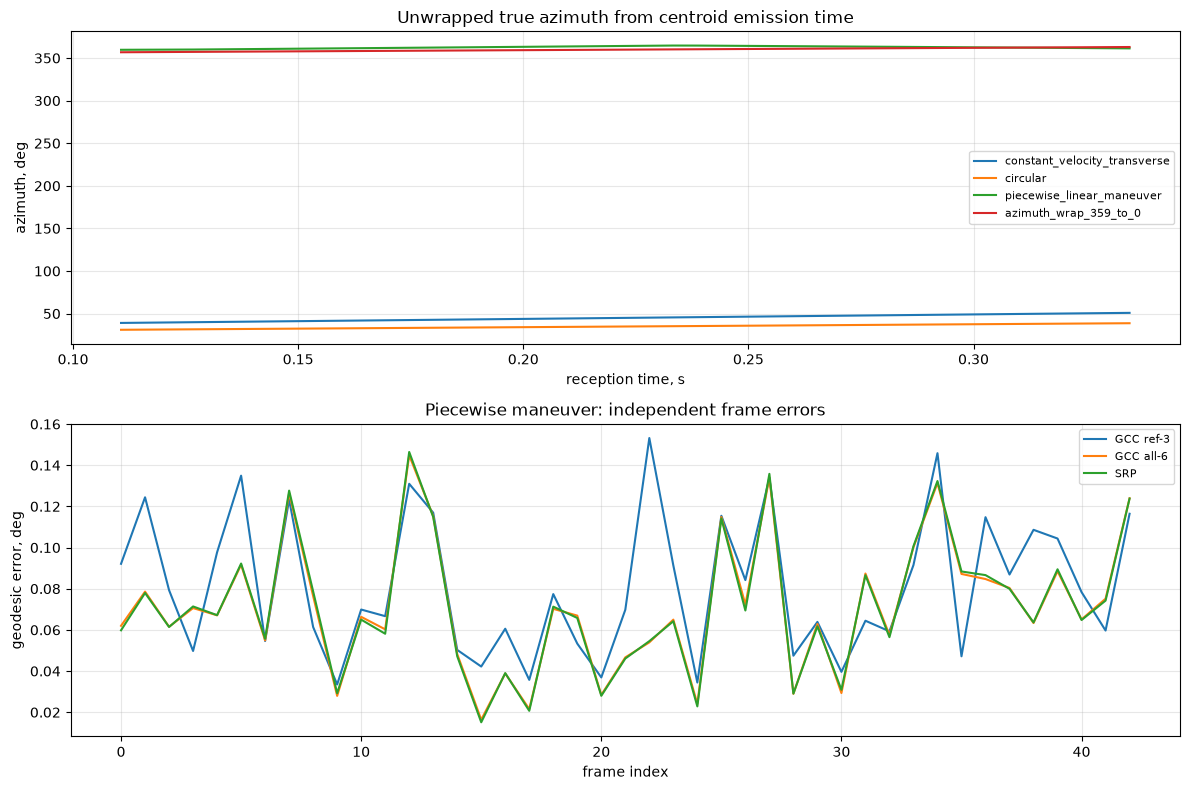

In [4]:
methods=['reference_3_gcc_wls','all_6_equal_gcc_wls','equal_weight_srp_phat']
labels={'reference_3_gcc_wls':'GCC ref-3','all_6_equal_gcc_wls':'GCC all-6','equal_weight_srp_phat':'SRP'}
fig,axes=plt.subplots(2,1,figsize=(12,8),sharex=False)
for name in ['constant_velocity_transverse','circular','piecewise_linear_maneuver','azimuth_wrap_359_to_0']:
    group=[r for r in frame_rows if r['sequence_name']==name and r['estimator_variant']=='reference_3_gcc_wls']
    t=np.array([r['frame_center_reception_time_s'] for r in group])
    az=np.rad2deg(np.unwrap(np.deg2rad([r['truth_azimuth_deg'] for r in group])))
    axes[0].plot(t,az,label=name)
for method in methods:
    group=[r for r in frame_rows if r['sequence_name']=='piecewise_linear_maneuver' and r['estimator_variant']==method and r['valid']]
    axes[1].plot([r['frame_index'] for r in group],[r['geodesic_angular_error_deg'] for r in group],label=labels[method])
axes[0].set(title='Unwrapped true azimuth from centroid emission time',ylabel='azimuth, deg',xlabel='reception time, s')
axes[1].set(title='Piecewise maneuver: independent frame errors',ylabel='geodesic error, deg',xlabel='frame index')
for ax in axes: ax.grid(True,alpha=.3); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

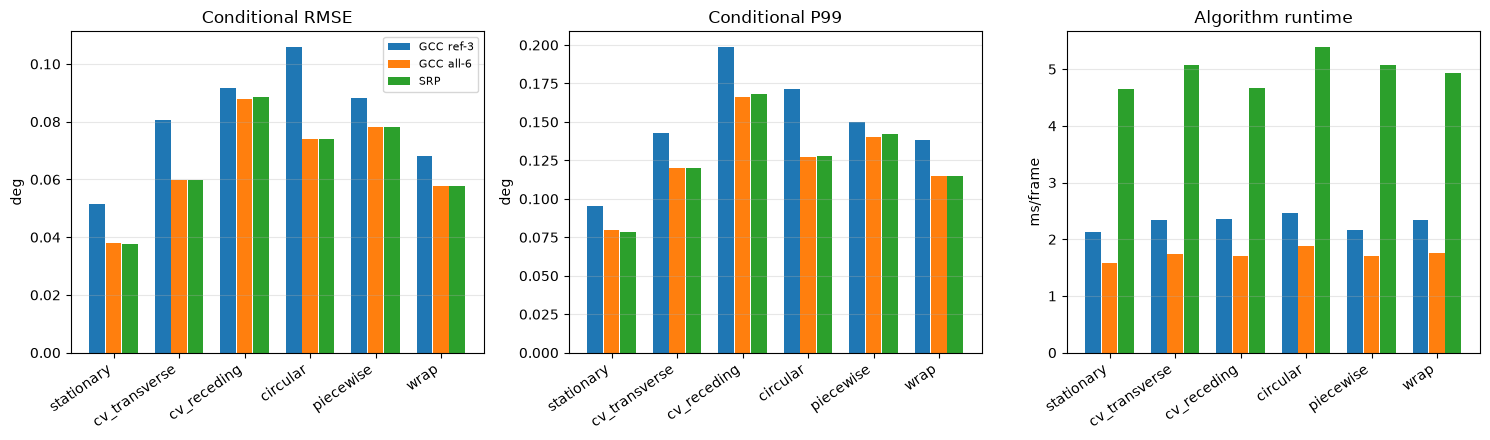

low-SNR/dropout coverage: {'GCC ref-3': 0.8837209302325582, 'GCC all-6': 0.8837209302325582, 'SRP': 0.8837209302325582}
frame-center acquisition latency, ms: 10.656249999999993
mean physical-delay range, ms: 72.87362258953168 76.56228378273414


In [5]:
normal=[r for r in summary_rows if r['sequence_name']!='low_snr_with_invalid_dropout']
fig,axes=plt.subplots(1,3,figsize=(15,4.5))
x=np.arange(6); names=[]
for i,name in enumerate(dict.fromkeys(r['sequence_name'] for r in normal)):
    names.append(name.replace('constant_velocity_','cv_').replace('piecewise_linear_maneuver','piecewise').replace('azimuth_wrap_359_to_0','wrap'))
for offset,method in zip((-0.25,0,0.25),methods):
    group=[r for r in normal if r['estimator_variant']==method]
    axes[0].bar(x+offset,[r['conditional_rmse_deg'] for r in group],width=.24,label=labels[method])
    axes[1].bar(x+offset,[r['conditional_p99_deg'] for r in group],width=.24,label=labels[method])
    axes[2].bar(x+offset,[1000*r['mean_algorithm_runtime_s'] for r in group],width=.24,label=labels[method])
for ax,title,ylabel in zip(axes,['Conditional RMSE','Conditional P99','Algorithm runtime'],['deg','deg','ms/frame']):
    ax.set_title(title); ax.set_ylabel(ylabel); ax.set_xticks(x,names,rotation=35,ha='right'); ax.grid(True,axis='y',alpha=.3)
axes[0].legend(fontsize=8); fig.tight_layout(); plt.show()
low=[r for r in summary_rows if r['sequence_name']=='low_snr_with_invalid_dropout']
print('low-SNR/dropout coverage:', {labels[r['estimator_variant']]:r['coverage'] for r in low})
print('frame-center acquisition latency, ms:', 1000*summary_rows[0]['frame_acquisition_latency_s'])
print('mean physical-delay range, ms:', 1000*min(r['mean_physical_propagation_delay_s'] for r in summary_rows), 1000*max(r['mean_physical_propagation_delay_s'] for r in summary_rows))

In [6]:
stationary=[r for r in summary_rows if r['sequence_name']=='stationary']
wrap=[r for r in summary_rows if r['sequence_name']=='azimuth_wrap_359_to_0']
assert all(r['maximum_truth_doa_change_from_first_deg']==0 for r in stationary)
assert all(r['azimuth_wrap_359_to_0_present'] for r in wrap)
print('stationary RMSE:', {labels[r['estimator_variant']]:r['conditional_rmse_deg'] for r in stationary})
print('wrap RMSE:', {labels[r['estimator_variant']]:r['conditional_rmse_deg'] for r in wrap})
print('Frames overlap and are statistically dependent; frame_count is not an independent-trial count.')

stationary RMSE: {'GCC ref-3': 0.05142054861689981, 'GCC all-6': 0.0380777491413633, 'SRP': 0.037554697085865785}
wrap RMSE: {'GCC ref-3': 0.06809839166061935, 'GCC all-6': 0.05770332930185574, 'SRP': 0.057860498124821996}
Frames overlap and are statistically dependent; frame_count is not an independent-trial count.


## Scope

The estimators use only the current frame. There is no EKF, UKF, alpha-beta filter, smoothing, future-bearing access, reflection, wind, correlated background, or SRP-Harmonics. No estimated 3D source position is produced; a single station returns bearings only.